In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# parameters definition
P0 = 0.3
Q0 = 0.9
r = 1.2
u = 0.2
s = 2
a = 0.5
K = 1

In [2]:
# system definition
def f(P, Q):
    dPdt = r*P*(1 - P/K) - s*P*Q
    dQdt = -u*Q + a*s*P*Q
    return np.array([dPdt, dQdt])

In [5]:
# equilibrium points 
P_star = u / (a * s)
Q_star = r / s * (1 - P_star / K)

print("Equilibrium points:")
print("E0 =", (0, 0))
print("E1 =", (K, 0))
print("E2 =", (P_star, Q_star))

Equilibrium points:
E0 = (0, 0)
E1 = (1, 0)
E2 = (0.2, 0.48)


In [6]:
# jacobian matrix
def jacobian(P, Q):
    J = np.array([
        [r*(1 - 2*P/K) - s*Q, -s*P],
        [a*s*Q, -u + a*s*P]
    ])
    return J

# stability points
def stability(P, Q):
    J = jacobian(P, Q)
    eigvals = np.linalg.eigvals(J)
    return eigvals

print("Eigenvalues for qquilibrium points:")
print("E0:", stability(0, 0))
print("E1:", stability(K, 0))
print("E2:", stability(P_star, Q_star))


Eigenvalues for qquilibrium points:
E0: [ 1.2 -0.2]
E1: [-1.2  0.8]
E2: [-0.12+0.42142615j -0.12-0.42142615j]


In [7]:
# numerical methods
def euler(f, y0, T, dt):
    N = int(T/dt)
    y = np.zeros((N+1, len(y0)))
    y[0] = y0
    for n in range(N):
        y[n+1] = y[n] + dt*f(y[n][0], y[n][1])
    return y

def rk2(f, y0, T, dt):
    N = int(T/dt)
    y = np.zeros((N+1, len(y0)))
    y[0] = y0
    for n in range(N):
        k1 = f(y[n][0], y[n][1])
        k2 = f(y[n][0] + dt*k1[0]/2, y[n][1] + dt*k1[1]/2)
        y[n+1] = y[n] + dt*k2
    return y

def rk4(f, y0, T, dt):
    N = int(T/dt)
    y = np.zeros((N+1, len(y0)))
    y[0] = y0
    for n in range(N):
        k1 = f(y[n][0], y[n][1])
        k2 = f(y[n][0] + dt*k1[0]/2, y[n][1] + dt*k1[1]/2)
        k3 = f(y[n][0] + dt*k2[0]/2, y[n][1] + dt*k2[1]/2)
        k4 = f(y[n][0] + dt*k3[0], y[n][1] + dt*k3[1])
        y[n+1] = y[n] + dt*(k1 + 2*k2 + 2*k3 + k4)/6
    return y

In [10]:
def plot_results(y, T, dt, method_name):
    t = np.linspace(0, T, len(y))  
    plt.figure(figsize=(10,5))
    
    # popuation trajectory
    plt.plot(t, y[:,0], label='Rabbit P(t)', color='hotpink')
    plt.plot(t, y[:,1], label='Fox Q(t)', color='royalblue')
    
    # equilibrum points
    plt.scatter(0, 0, color='black', marker='x', s=100, label='E0 (0,0)')
    plt.scatter(0, K, color='violet', marker='o', s=100, label=f'E1 (K,0) = ({K},0)')
    plt.scatter(0, Q_star, color='pink', marker='s', s=100, label=f'E2 (P*,Q*) = ({P_star:.2f},{Q_star:.2f})')

    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title(f"Method {method_name}, dt={dt}")
    plt.legend()
    plt.grid(True)
    plt.show()

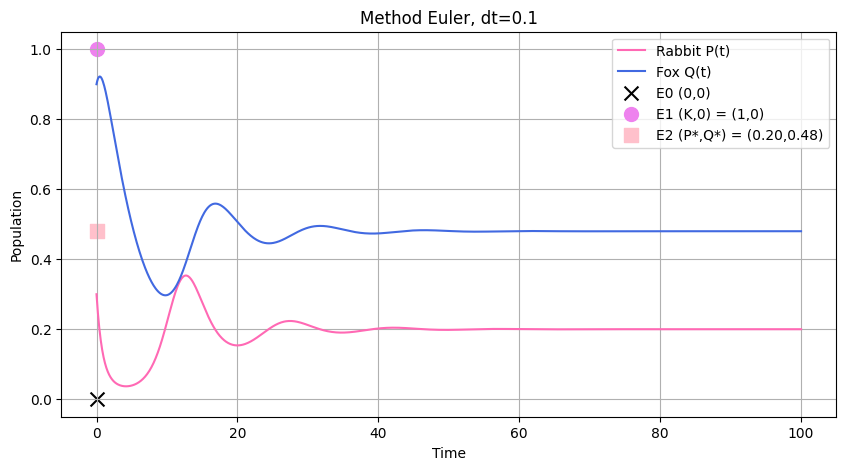

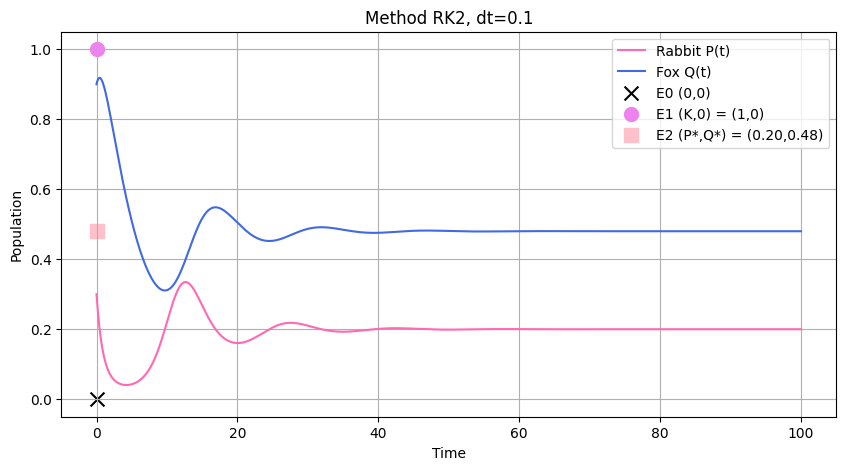

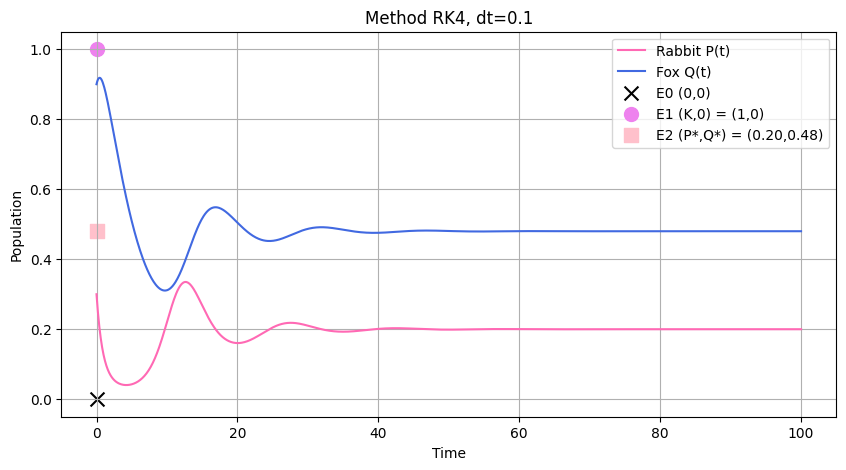

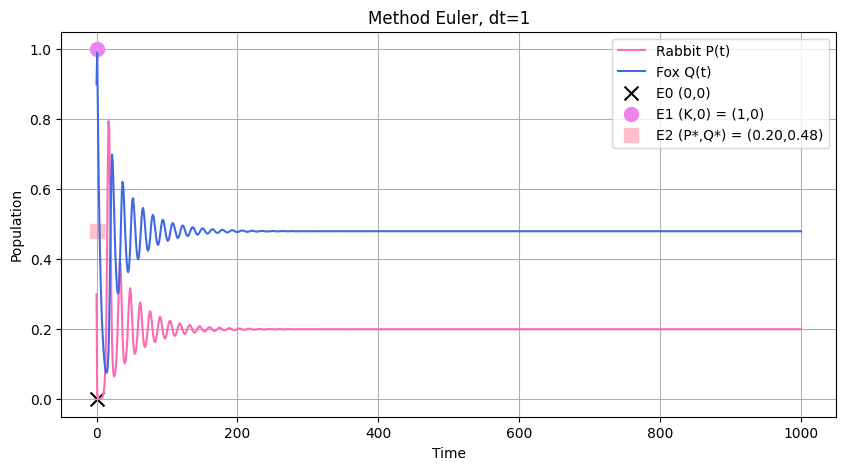

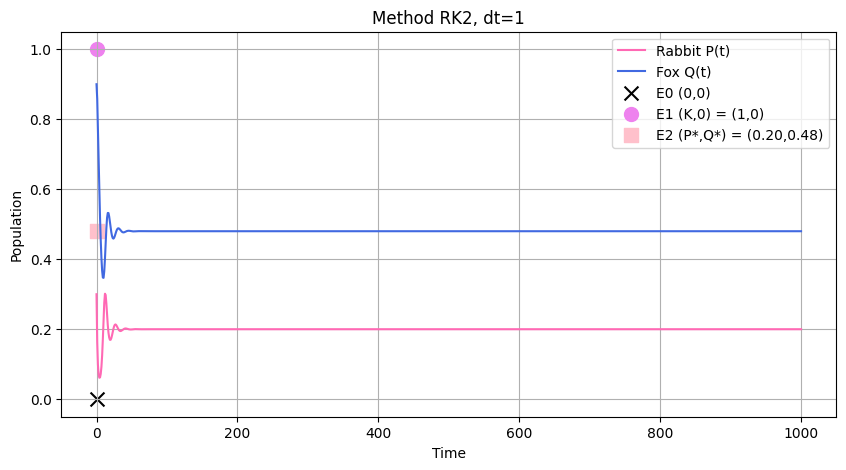

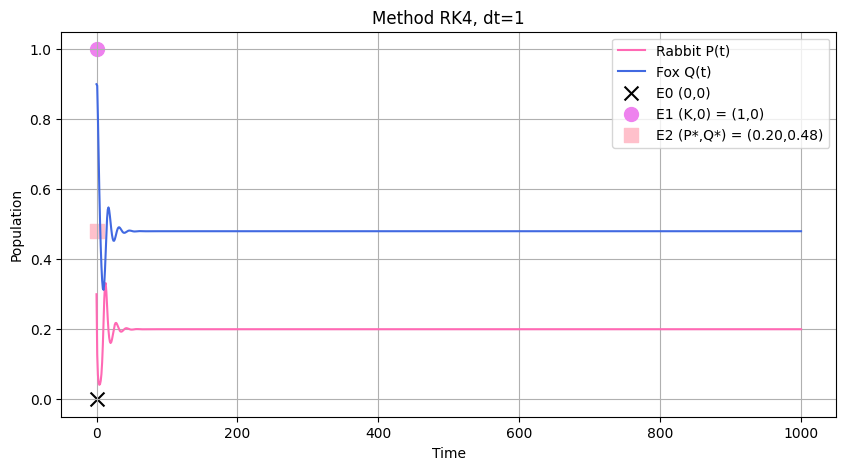

/var/folders/21/rtkg0zs945n81z3ngx943kz00000gn/T/ipykernel_14634/1600258420.py:3: RuntimeWarning: overflow encountered in scalar multiply
  dPdt = r*P*(1 - P/K) - s*P*Q
/var/folders/21/rtkg0zs945n81z3ngx943kz00000gn/T/ipykernel_14634/1600258420.py:4: RuntimeWarning: overflow encountered in scalar multiply
  dQdt = -u*Q + a*s*P*Q
/var/folders/21/rtkg0zs945n81z3ngx943kz00000gn/T/ipykernel_14634/1600258420.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  dPdt = r*P*(1 - P/K) - s*P*Q
/var/folders/21/rtkg0zs945n81z3ngx943kz00000gn/T/ipykernel_14634/599975732.py:7: RuntimeWarning: invalid value encountered in add
  y[n+1] = y[n] + dt*f(y[n][0], y[n][1])


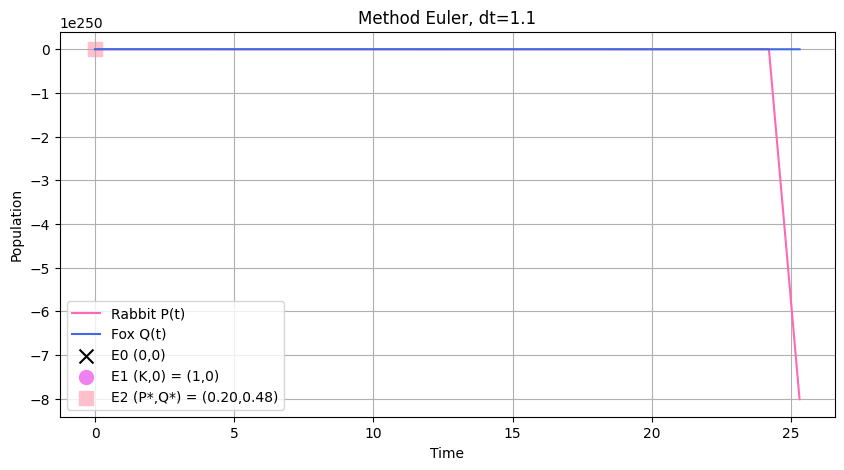

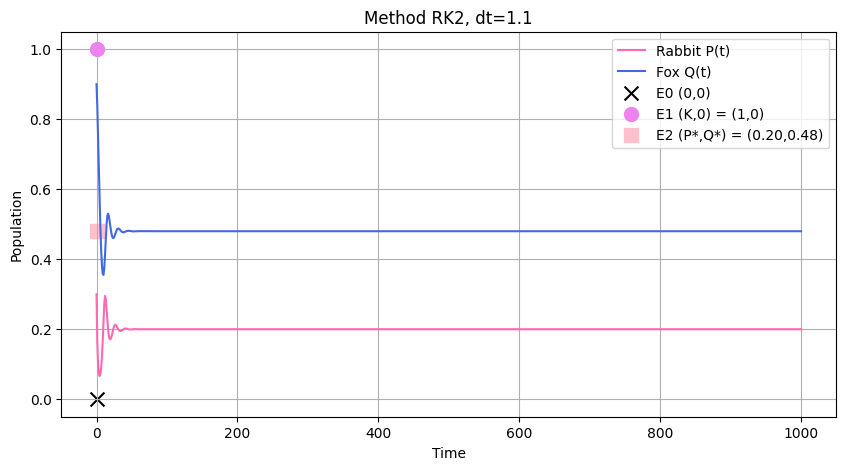

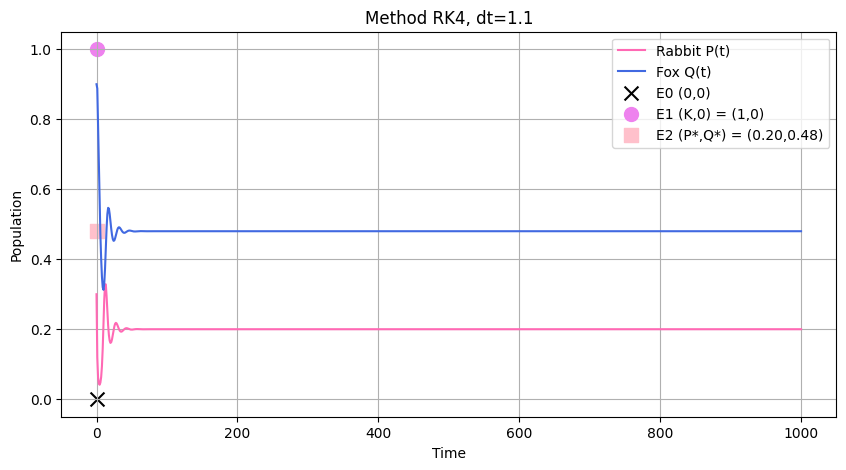

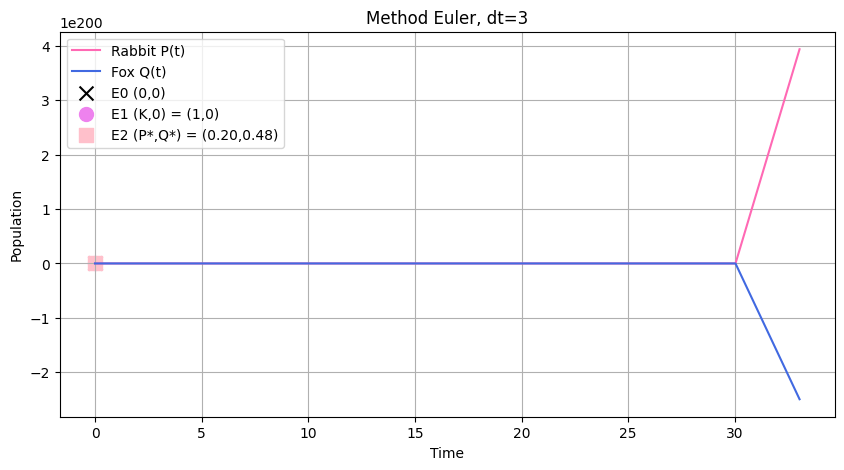

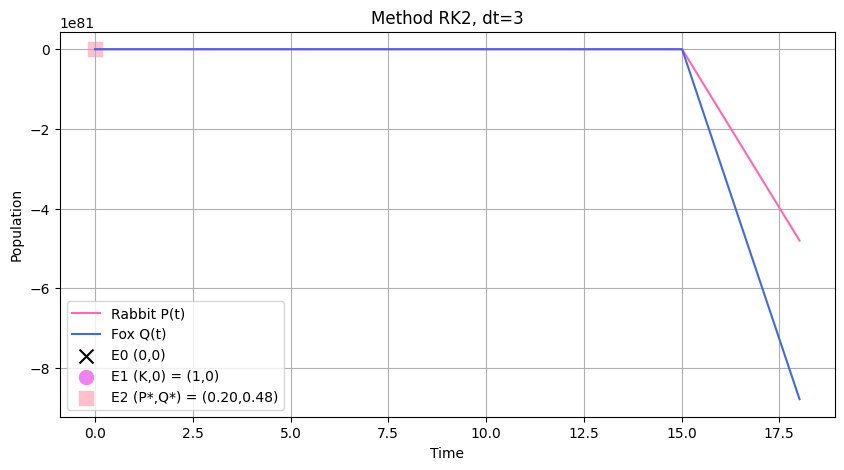

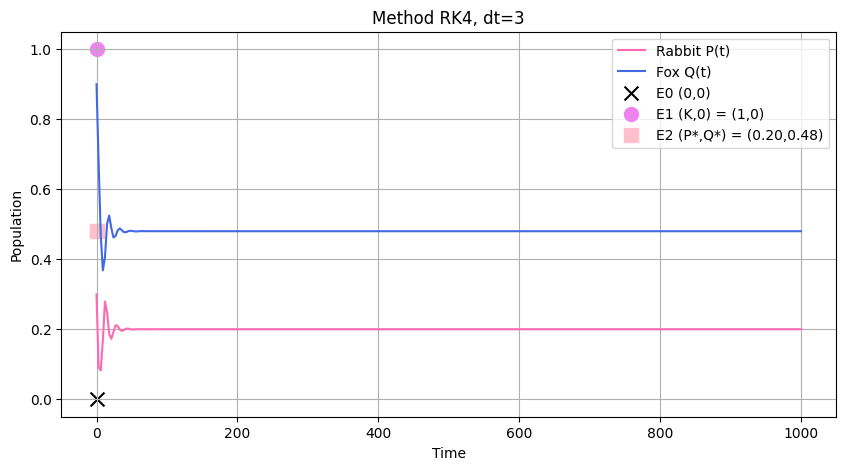

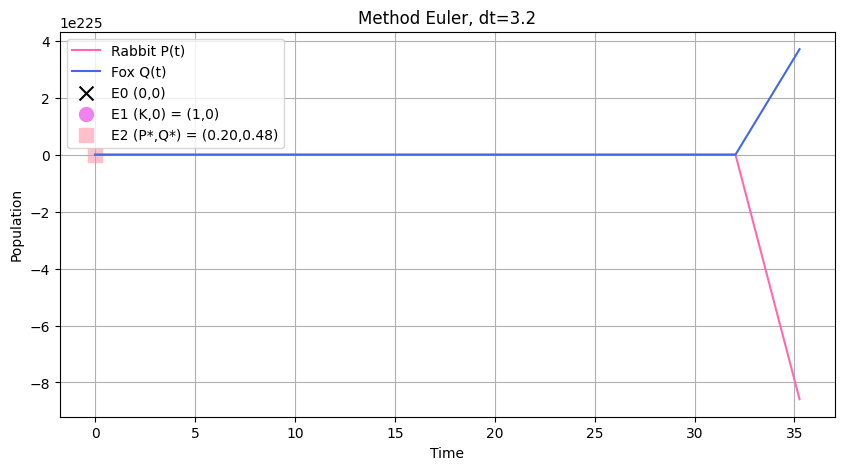

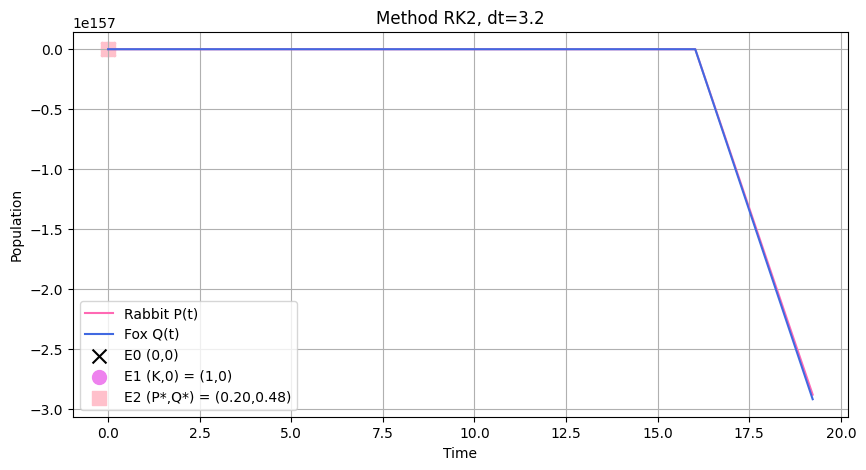

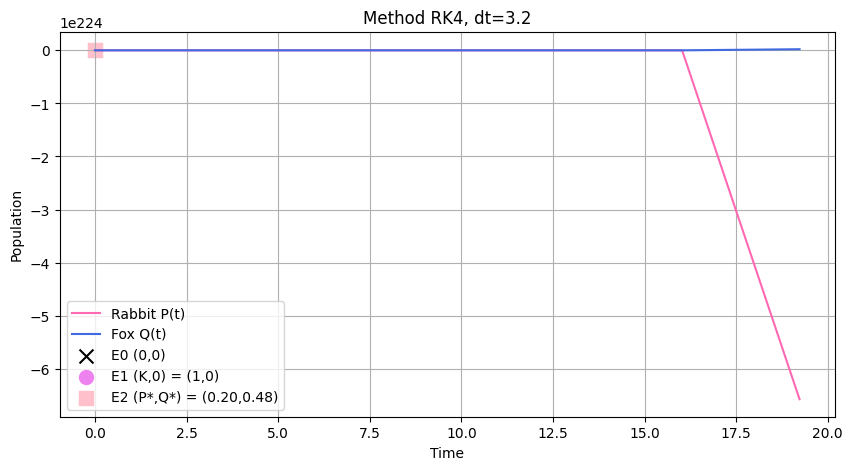

In [11]:
# simulations
params = [
    (100, 0.1),
    (1000, 1),
    (1000, 1.1),
    (1000, 3),
    (1000, 3.2)
]

methods = {'Euler': euler, 'RK2': rk2, 'RK4': rk4}

for T, dt in params:
    for name, method in methods.items():
        y = method(f, np.array([P0, Q0]), T, dt)
        plot_results(y, T, dt, name)

### Stability Analysis

1. **E0 = (0, 0)**  
   - Unstable saddle point.  
   - Any small introduction of the prey population leads to its growth, moving the system away from this state.  
   - Trajectories never converge to (0,0) unless both species have an initial population of zero.

2. **E1 = (K, 0)**  
   - Unstable saddle point: prey is at maximum environmental capacity, predators are absent.  
   - If the predator population is slightly greater than 0, the system deviates toward the coexistence point (E2).  

3. **E2 = (P*, Q*) = (u / (a*s), (r/s)*(1 - u/(a*s*K)))**  
   - Stable coexistence equilibrium.  
   - The system oscillates around this point, which is typical for Lotka-Volterra predator-prey dynamics with logistic prey growth.  
   - Oscillations are more pronounced with higher initial populations or a larger attack rate parameter.  

### Numerical Methods Evaluation

- **Euler Method**: The simplest but least stable approach. At large time steps (Δt), the trajectory rapidly diverges, displaying unstable numerical growth or decay.  
- **RK2 (Midpoint Method)**: Offers better accuracy and stability than Euler, handling moderate time steps effectively.  
- **RK4 (Runge-Kutta 4th Order)**: The most robust and accurate method. It maintains stability and correctly captures oscillatory behavior even at significantly larger steps (Δt).

### Impact of Time Step (Δt)

- **Small Δt (0.1)**: All methods accurately simulate the system's oscillations around the coexistence point.  
- **Medium Δt (1.0 - 1.1)**: The Euler method begins to diverge significantly, whereas RK2 and RK4 remain stable.  
- **Large Δt (≥ 3.0)**: Euler trajectories become entirely unstable. RK4 maintains the correct oscillatory shape, although some numerical artifacts may appear due to the extreme step size.